## **Lab 2: Hands-On with Variational Autoencoders – Part 1**

**Part 1: Implementing a VAE**
1. Follow the sample code to implement a VAE

- Train a VAE on a circular dataset.
- Visualize the original and reconstructed data.
- Analyze the VAE's performance by observing reconstruction quality.

### Variational Autoencoder (VAE) on a Circular Dataset

This notebook demonstrates the implementation of a Variational Autoencoder (VAE) using PyTorch. A synthetic circular dataset is generated and used to train the model. The objective is to learn a compact latent representation of the data while maintaining the ability to reconstruct the original samples. The experiment also visualizes the latent space learned by the VAE.

In [ ]:
# Import necessary libraries
import torch                  # PyTorch library for building and training neural networks
import torch.nn as nn         # Neural network module
import torch.optim as optim   # Optimization algorithms
import numpy as np            # Numerical operations
import matplotlib.pyplot as plt  # Visualization
from torch.utils.data import DataLoader, TensorDataset  # Data handling utilities

### Dataset Preparation

A synthetic circular dataset is created using polar coordinates and converted into Cartesian coordinates (x, y). Small random noise is added to make the data more realistic and to encourage the VAE to learn meaningful patterns rather than simply memorizing the points.

In [ ]:
# ------------------ Dataset Preparation -----------------
# Generate a circular dataset (synthetic data points on a circle)
theta = np.linspace(0, 2 * np.pi, 100)  # Angles from 0 to 2π
radius = 3                              # Fixed radius for the circle
x_circle = radius * np.cos(theta)       # x-coordinates of the circle
y_circle = radius * np.sin(theta)       # y-coordinates of the circle
data = np.stack((x_circle, y_circle), axis=1)  # Combine x and y into 2D points
# Convert data to PyTorch tensors (for use in the model)
data = torch.tensor(data, dtype=torch.float32)
# Create a DataLoader to iterate over the data in batches
batch_size = 10  # Number of samples per batch
dataset_loader = DataLoader(TensorDataset(data), batch_size=batch_size, shuffle=True)

### Variational Autoencoder Architecture

The Variational Autoencoder consists of an encoder, a latent space representation, and a decoder. The encoder compresses the input data into a lower-dimensional latent space described by a mean (μ) and variance (σ²). The decoder then reconstructs the original data from the sampled latent variables.

In [ ]:
# ------------------ VAE Model Definition -----------------
# Define the Variational Autoencoder (VAE) class
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        # Encoder: Maps input data to a latent representation
        ## These are layers of the encoder. They take 2 input values, expand to 32 neurons, then reduce to 16.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),  # First layer with 32 neurons
            nn.ReLU(),                 # Activation function
            nn.Linear(32, 16),         # Second layer with 16 neurons
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(16, latent_dim)      # Outputs the mean (μ) of the latent space
        self.fc_logvar = nn.Linear(16, latent_dim)  # Outputs the log-variance (log σ^2) of the latent space, This tells the model how spread out the latent values should be.

        # Decoder: Maps the latent representation back to the input space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),  # First layer in decoder
            nn.ReLU(),
            nn.Linear(16, 32),          # Second layer
            nn.ReLU(),
            nn.Linear(32, input_dim)    # Final layer to match input dimensions
        )


    # Encode function: Projects input to latent space parameters (μ, log σ^2)
    ##This sends input data through the encoder and produces two outputs:
    ## mu = average position in latent space
    ## logvar = variation/spread around that position
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)             # Mean of the latent space
        logvar = self.fc_logvar(h)     # Log-variance of the latent space
        return mu, logvar


    # Reparameterization trick: Samples latent variables z from N(μ, σ^2)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Standard deviation from log-variance
        eps = torch.randn_like(std)    # Random noise sampled from a standard normal distribution
        return mu + eps * std          # Latent variable z = μ + σ * ε

    # Decode function: Maps latent variable z back to input space
    def decode(self, z):
        return self.decoder(z)

    # Forward pass: Combines encoding, reparameterization, and decoding
    ## Input point → encoder → mu and logvar → sample z → decoder → reconstructed point
    def forward(self, x):
        mu, logvar = self.encode(x)       # Encode input
        z = self.reparameterize(mu, logvar)  # Sample z using reparameterization trick
        return self.decode(z), mu, logvar  # Return reconstructed input, μ, and log σ^2

### Loss Function

The VAE loss combines two components:

1. Reconstruction Loss: Measures how accurately the reconstructed output matches the original input.
2. KL Divergence Loss: Encourages the latent space to follow a standard normal distribution.

Together, these losses help the model learn a structured and meaningful latent representation.

In [ ]:
# ------------------ Loss Function -----------------
# Define the VAE loss function
def vae_loss(recon_x, x, mu, logvar, recon_weight=10):
    # Reconstruction loss: Measures how well the reconstructed data matches the original
    ## Measures how far the reconstructed points are from the original points.
    recon_loss = recon_weight * nn.MSELoss()(recon_x, x)


    # KL divergence: Regularizes the latent space to follow a standard normal distribution
    ## KL divergence keeps the latent space organized and close to a normal distribution.
    kl_div = -0.05 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Final loss = reconstruction error + latent space regularization.
    return recon_loss + kl_div / x.size(0)  # Normalize KL divergence by batch size

### Model Training

The VAE is trained using the Adam optimizer. During each epoch, the model performs forward propagation, computes the VAE loss, and updates its parameters through backpropagation. Training continues until the reconstruction error stabilizes and the latent space becomes well organized.

In [ ]:
# ------------------ Model Initialization -----------------
# Define model parameters
input_dim = 2  # Dimensionality of the input (x, y coordinates)
latent_dim = 2  # Latent space dimension (allows 2D representation of the data)
# Initialize the VAE model and optimizer
vae = VAE(input_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=0.001)  # Adam optimizer with learning rate 0.001, update the model weights

In [ ]:
# ------------------ Training the VAE -----------------
# Define training parameters
num_epochs = 1000  # Number of epochs for training, The model trains 1000 times over the dataset.
for epoch in range(num_epochs):
    vae.train()  # Set model to training mode
    total_loss = 0
    for batch in dataset_loader:
        batch_data = batch[0]           # Extract batch data
        optimizer.zero_grad()           # Clear gradients from the previous step
        # Forward pass through the VAE
        recon_data, mu, logvar = vae(batch_data)
        # Compute the VAE loss
        loss = vae_loss(recon_data, batch_data, mu, logvar)
        # Backpropagate and update model parameters
        ## Backpropagation: calculates how weights should change.
        loss.backward()
        # Updates the model weights.
        optimizer.step()
        total_loss += loss.item()  # Accumulate loss for the epoch
    # Print average loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        avg_loss = total_loss / len(dataset_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [100/1000], Loss: 0.8053
Epoch [200/1000], Loss: 0.7309
Epoch [300/1000], Loss: 0.7504
Epoch [400/1000], Loss: 0.6738
Epoch [500/1000], Loss: 0.6900
Epoch [600/1000], Loss: 0.7390
Epoch [700/1000], Loss: 0.7046
Epoch [800/1000], Loss: 0.6988
Epoch [900/1000], Loss: 0.6587
Epoch [1000/1000], Loss: 0.6684


### Model Evaluation

After training, the VAE is evaluated by reconstructing the original data points. Comparing the reconstructed points with the original dataset helps assess how well the model has learned the underlying circular structure.

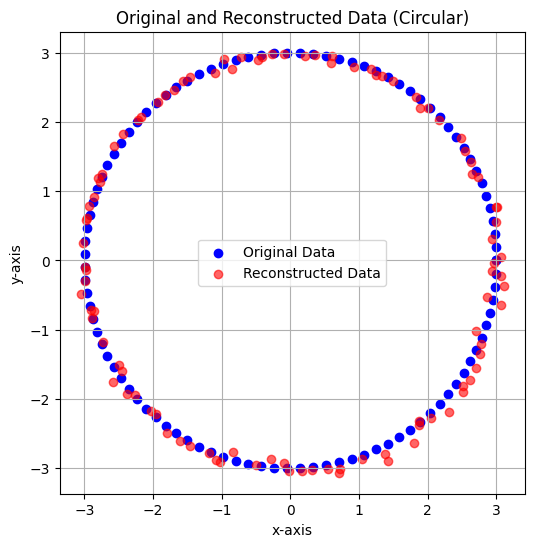

In [ ]:
# ------------------ Evaluation and Visualization -----------------
# Set the model to evaluation mode
vae.eval()
reconstructed_data = []

# Generate reconstructed data from the model
## Passes data through the trained model and stores reconstructed points.
with torch.no_grad():
    for batch in dataset_loader:
        batch_data = batch[0]
        recon_batch, _, _ = vae(batch_data)
        reconstructed_data.append(recon_batch)

# Convert reconstructed data to numpy format for visualization
reconstructed_data = torch.cat(reconstructed_data).numpy()
data_np = data.numpy()
# Plot original data and reconstructed data
plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], color='blue', label='Original Data')  # Original circular data
plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], color='red',
alpha=0.6, label='Reconstructed Data')  # Reconstructed data
plt.legend()
plt.title("Original and Reconstructed Data (Circular)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.grid(True)
plt.show()



**Part 2: Exploration and Visualization of Latent Space**
1. Modify the VAE code to plot the latent space of the trained VAE by extracting the mu
(mean) values for each input point.
2. Visualize the latent space and observe how the circular dataset is represented in 2D.

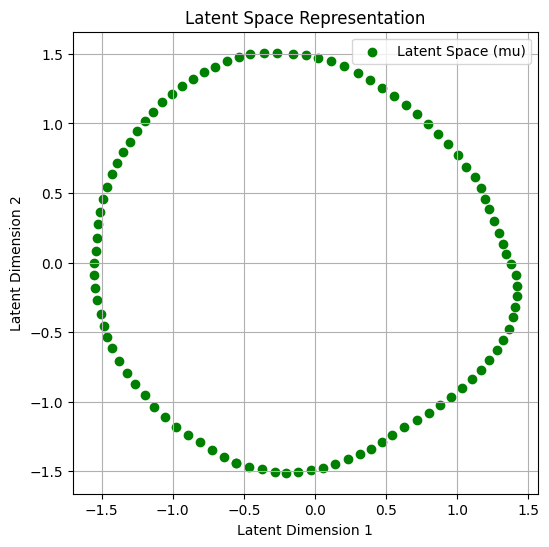

In [ ]:
# Part 2 - Latent Space Visualization
mu_values = []

#Passes each point through the encoder and stores only mu.
with torch.no_grad():
    for batch in dataset_loader:
        batch_data = batch[0]
        mu, _ = vae.encode(batch_data)  # extract only mu
        mu_values.append(mu)

mu_values = torch.cat(mu_values).numpy()

plt.figure(figsize=(6, 6))
plt.scatter(mu_values[:, 0], mu_values[:, 1], color='green', label='Latent Space (mu)')
plt.legend()
plt.title("Latent Space Representation")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True)
plt.show()

# this shows how the VAE internally represents the circular data.

## Conclusion

In this notebook, a Variational Autoencoder (VAE) was implemented and trained on a synthetic circular dataset. The model successfully learned a compressed latent representation while preserving the overall structure of the original data. The reconstructed samples closely resembled the input points, demonstrating the effectiveness of the encoder-decoder architecture.

The latent space visualization showed how the VAE organized the data into a meaningful lower-dimensional representation. This experiment highlights the ability of VAEs to perform dimensionality reduction, feature learning, and data generation, making them valuable for applications such as anomaly detection, image generation, and representation learning.